In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import seaborn as sns
from io import StringIO

In [3]:
df_fuel = pd.read_csv("aggregated_data.csv")
df_fuel.rename(columns={'quater': 'quarter'}, inplace=True)
df_fuel

,airline_id,name,aircraft_type,time,ln_fuel,ln_number_of_flights,ln_airborne_hours,ln_distance,ln_payload,ln_average_fuel_price,ln_fuel_price_t_minus_1,ln_fuel_price_t_minus_2,ln_fuel_price_t_minus_3,ln_fuel_price_t_minus_4,ln_fuel_price_t_minus_5,ln_fuel_price_t_minus_6,ln_fuel_price_t_minus_7,ln_fuel_price_t_minus_8,quarter
0,19393,WN,B737-700,1,12.277946,12.016352,5.613529,14.722445,22.526884,0.717292,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
1,19393,WN,B737-700,2,12.394476,12.083300,5.710228,14.728212,22.593832,0.738457,0.717292,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
2,19393,WN,B737-700,3,12.417688,12.089808,5.712907,14.728918,22.600340,0.716068,0.738457,0.717292,NaN,NaN,NaN,NaN,NaN,NaN,3
3,19393,WN,B737-700,4,12.394437,12.076920,5.710692,14.747481,22.587452,0.821106,0.716068,0.738457,0.717292,NaN,NaN,NaN,NaN,NaN,4
4,19393,WN,B737-700,5,12.391647,12.077216,5.715777,14.745829,22.587748,0.990071,0.821106,0.716068,0.738457,0.717292,NaN,NaN,NaN,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1962,21171,VX,A320,28,10.643799,9.590556,3.855664,12.760435,20.114324,0.301465,0.202756,0.193015,-0.044774,0.182850,0.291972,0.484861,0.418842,0.676828,4
1963,21171,VX,A320,29,10.568464,9.515248,3.791887,12.777984,20.039017,0.333447,0.301465,0.202756,0.193015,-0.044774,0.182850,0.291972,0.484861,0.418842,1
1964,21171,VX,A320,30,10.680976,9.584452,4.002047,12.717404,20.108221,0.260024,0.333447,0.301465,0.202756,0.193015,-0.044774,0.182850,0.291972,0.484861,2
1965,21171,VX,A320,31,10.690193,9.590351,4.007878,12.777609,20.114119,0.379957,0.260024,0.333447,0.301465,0.202756,0.193015,-0.044774,0.182850,0.291972,3


## 1 OLS

In [17]:
import pandas as pd
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# 数据预处理
X = pd.get_dummies(df_fuel[['ln_number_of_flights', 'ln_airborne_hours', 'ln_distance', 
                            'ln_payload', 'ln_average_fuel_price', 'airline_id', 'quarter', 'aircraft_type']], 
                   drop_first=True)
y = df_fuel['ln_fuel']

X = sm.add_constant(X)

# 数据拆分
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=69)

# 训练OLS模型
ols_model = sm.OLS(y_train, X_train).fit()

# 输出模型摘要
print(ols_model.summary())

# 预测
y_train_pred = ols_model.predict(X_train)
y_test_pred = ols_model.predict(X_test)

# 计算训练集和测试集的 R-squared 和 RMSE
r_squared_train = r2_score(y_train, y_train_pred)
rmse_train = mean_squared_error(y_train, y_train_pred, squared=False)

r_squared_test = r2_score(y_test, y_test_pred)
rmse_test = mean_squared_error(y_test, y_test_pred, squared=False)

# 输出结果
print(f"Training R-squared: {r_squared_train:.4f}")
print(f"Training RMSE: {rmse_train:.4f}")
print(f"Testing R-squared: {r_squared_test:.4f}")
print(f"Testing RMSE: {rmse_test:.4f}")

                            OLS Regression Results                            
Dep. Variable:                ln_fuel   R-squared:                       0.982
Model:                            OLS   Adj. R-squared:                  0.981
Method:                 Least Squares   F-statistic:                     5169.
Date:                Wed, 04 Dec 2024   Prob (F-statistic):               0.00
Time:                        10:56:43   Log-Likelihood:                -15.804
No. Observations:                1376   AIC:                             61.61
Df Residuals:                    1361   BIC:                             140.0
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      8

## 2 CART

In [16]:
import pandas as pd
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# 数据准备
X = pd.get_dummies(df_fuel[['ln_number_of_flights', 'ln_airborne_hours', 'ln_distance', 
                            'ln_payload', 'ln_average_fuel_price', 'airline_id', 'quarter', 'aircraft_type']], 
                   drop_first=True)
y = df_fuel['ln_fuel']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=69)

# CART 模型训练
cart_model = DecisionTreeRegressor(random_state=69)
cart_model.fit(X_train, y_train)

# 预测
y_train_pred_cart = cart_model.predict(X_train)  # 训练集预测
y_test_pred_cart = cart_model.predict(X_test)   # 测试集预测

# 计算训练集和测试集的 R-squared 和 RMSE
r_squared_train = r2_score(y_train, y_train_pred_cart)
rmse_train = mean_squared_error(y_train, y_train_pred_cart, squared=False)

r_squared_test = r2_score(y_test, y_test_pred_cart)
rmse_test = mean_squared_error(y_test, y_test_pred_cart, squared=False)

# 输出结果
print(f"Training R-squared: {r_squared_train:.4f}")
print(f"Training RMSE: {rmse_train:.4f}")
print(f"Testing R-squared: {r_squared_test:.4f}")
print(f"Testing RMSE: {rmse_test:.4f}")

# 输出特征重要性
feature_importances = cart_model.feature_importances_
print("\nFeature Importances:")
for feature, importance in zip(X.columns, feature_importances):
    print(f"{feature}: {importance:.4f}")

Training R-squared: 1.0000
Training RMSE: 0.0000
Testing R-squared: 0.9638
Testing RMSE: 0.3439

Feature Importances:
ln_number_of_flights: 0.0117
ln_airborne_hours: 0.9609
ln_distance: 0.0018
ln_payload: 0.0083
ln_average_fuel_price: 0.0013
airline_id: 0.0062
quarter: 0.0001
aircraft_type_A320: 0.0004
aircraft_type_B737-700: 0.0011
aircraft_type_B737-800: 0.0001
aircraft_type_B737-900: 0.0004
aircraft_type_B757-200: 0.0011
aircraft_type_B767-300: 0.0016
aircraft_type_B777: 0.0049


## 3 Random Forest

In [18]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

# 数据准备
X = pd.get_dummies(df_fuel[['ln_number_of_flights', 'ln_airborne_hours', 'ln_distance', 
                            'ln_payload', 'ln_average_fuel_price', 'airline_id', 'quarter', 'aircraft_type']], 
                   drop_first=True)
y = df_fuel['ln_fuel']

# 数据拆分
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=69)

# 随机森林模型训练
rf_model = RandomForestRegressor(
    n_estimators=100,  
    random_state=69,
    max_depth=None,   
    min_samples_split=2,
    min_samples_leaf=1
)
rf_model.fit(X_train, y_train)

# 预测
y_train_pred_rf = rf_model.predict(X_train)  # 训练集预测
y_test_pred_rf = rf_model.predict(X_test)   # 测试集预测

# 计算训练集和测试集的 R-squared 和 RMSE
r_squared_train_rf = r2_score(y_train, y_train_pred_rf)
rmse_train_rf = mean_squared_error(y_train, y_train_pred_rf, squared=False)

r_squared_test_rf = r2_score(y_test, y_test_pred_rf)
rmse_test_rf = mean_squared_error(y_test, y_test_pred_rf, squared=False)

# 输出训练集和测试集结果
print(f"Training R-squared: {r_squared_train_rf:.4f}")
print(f"Training RMSE: {rmse_train_rf:.4f}")
print(f"Testing R-squared: {r_squared_test_rf:.4f}")
print(f"Testing RMSE: {rmse_test_rf:.4f}")

# 输出特征重要性
feature_importances = rf_model.feature_importances_
print("\nFeature Importances:")
for feature, importance in zip(X.columns, feature_importances):
    print(f"{feature}: {importance:.4f}")

Training R-squared: 0.9973
Training RMSE: 0.0924
Testing R-squared: 0.9805
Testing RMSE: 0.2563

Feature Importances:
ln_number_of_flights: 0.0099
ln_airborne_hours: 0.9538
ln_distance: 0.0027
ln_payload: 0.0167
ln_average_fuel_price: 0.0022
airline_id: 0.0057
quarter: 0.0004
aircraft_type_A320: 0.0003
aircraft_type_B737-700: 0.0010
aircraft_type_B737-800: 0.0003
aircraft_type_B737-900: 0.0002
aircraft_type_B757-200: 0.0013
aircraft_type_B767-300: 0.0018
aircraft_type_B777: 0.0038


In [10]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

rf_model = RandomForestRegressor(n_estimators=100, random_state=69)

kf = KFold(n_splits=5, shuffle=True, random_state=69)

r2_scores = []
rmse_scores = []

for train_index, test_index in kf.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    rf_model.fit(X_train, y_train)
    
    y_pred = rf_model.predict(X_test)
    
    r2_scores.append(r2_score(y_test, y_pred))
    rmse_scores.append(mean_squared_error(y_test, y_pred, squared=False))

print(f"Average R-squared: {np.mean(r2_scores):.4f}")
print(f"Average RMSE: {np.mean(rmse_scores):.4f}")

Average R-squared: 0.9821
Average RMSE: 0.2388


## 4 XGBoost

In [19]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

# 数据准备
X = pd.get_dummies(df_fuel[['ln_number_of_flights', 'ln_airborne_hours', 'ln_distance', 
                            'ln_payload', 'ln_average_fuel_price', 'airline_id', 'quarter', 'aircraft_type']], 
                   drop_first=True)
y = df_fuel['ln_fuel']

# 数据拆分
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=69)

# XGBoost模型训练
xgb_model = XGBRegressor(
    n_estimators=100,       
    learning_rate=0.1,        
    max_depth=6,             
    subsample=0.8,           
    colsample_bytree=0.8,    
    random_state=69
)
xgb_model.fit(X_train, y_train)

# 预测
y_train_pred_xgb = xgb_model.predict(X_train)  # 训练集预测
y_test_pred_xgb = xgb_model.predict(X_test)    # 测试集预测

# 计算训练集和测试集的 R-squared 和 RMSE
r_squared_train_xgb = r2_score(y_train, y_train_pred_xgb)
rmse_train_xgb = mean_squared_error(y_train, y_train_pred_xgb, squared=False)

r_squared_test_xgb = r2_score(y_test, y_test_pred_xgb)
rmse_test_xgb = mean_squared_error(y_test, y_test_pred_xgb, squared=False)

# 输出训练集和测试集结果
print(f"Training R-squared: {r_squared_train_xgb:.4f}")
print(f"Training RMSE: {rmse_train_xgb:.4f}")
print(f"Testing R-squared: {r_squared_test_xgb:.4f}")
print(f"Testing RMSE: {rmse_test_xgb:.4f}")

# 输出特征重要性
feature_importances = xgb_model.feature_importances_
print("\nFeature Importances:")
for feature, importance in zip(X.columns, feature_importances):
    print(f"{feature}: {importance:.4f}")

Training R-squared: 0.9992
Training RMSE: 0.0503
Testing R-squared: 0.9782
Testing RMSE: 0.2712

Feature Importances:
ln_number_of_flights: 0.0251
ln_airborne_hours: 0.6347
ln_distance: 0.0078
ln_payload: 0.2013
ln_average_fuel_price: 0.0046
airline_id: 0.0166
quarter: 0.0022
aircraft_type_A320: 0.0024
aircraft_type_B737-700: 0.0206
aircraft_type_B737-800: 0.0050
aircraft_type_B737-900: 0.0219
aircraft_type_B757-200: 0.0108
aircraft_type_B767-300: 0.0178
aircraft_type_B777: 0.0291


## 5 Random Forest with only Price

In [24]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

# 数据准备
# X = pd.get_dummies(df_fuel[['ln_number_of_flights', 'ln_airborne_hours', 'ln_distance', 
#                            'ln_payload', 'ln_average_fuel_price', 'airline_id', 'quarter', 'aircraft_type']], 
#                  drop_first=True)

df_fuel = df_fuel.dropna()

X = pd.get_dummies(df_fuel[['ln_number_of_flights', 'ln_airborne_hours', 'ln_distance', 'ln_payload', 'airline_id', 'quarter', 'aircraft_type', 'ln_average_fuel_price', 'ln_fuel_price_t_minus_1', 'ln_fuel_price_t_minus_2','ln_fuel_price_t_minus_3',
                            'ln_fuel_price_t_minus_4', 'ln_fuel_price_t_minus_5','ln_fuel_price_t_minus_6', 'ln_fuel_price_t_minus_7', 'ln_fuel_price_t_minus_8']])
y = df_fuel['ln_fuel']

# 数据拆分
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=69)

# 随机森林模型训练
rf_model = RandomForestRegressor(
    n_estimators=100,  
    random_state=69,
    max_depth=None,   
    min_samples_split=2,
    min_samples_leaf=1
)
rf_model.fit(X_train, y_train)

# 预测
y_train_pred_rf = rf_model.predict(X_train)  # 训练集预测
y_test_pred_rf = rf_model.predict(X_test)   # 测试集预测

# 计算训练集和测试集的 R-squared 和 RMSE
r_squared_train_rf = r2_score(y_train, y_train_pred_rf)
rmse_train_rf = mean_squared_error(y_train, y_train_pred_rf, squared=False)

r_squared_test_rf = r2_score(y_test, y_test_pred_rf)
rmse_test_rf = mean_squared_error(y_test, y_test_pred_rf, squared=False)

# 输出训练集和测试集结果
print(f"Training R-squared: {r_squared_train_rf:.4f}")
print(f"Training RMSE: {rmse_train_rf:.4f}")
print(f"Testing R-squared: {r_squared_test_rf:.4f}")
print(f"Testing RMSE: {rmse_test_rf:.4f}")

# 输出特征重要性
feature_importances = rf_model.feature_importances_
print("\nFeature Importances:")
for feature, importance in zip(X.columns, feature_importances):
    print(f"{feature}: {importance:.4f}")

Training R-squared: 0.9967
Training RMSE: 0.1064
Testing R-squared: 0.9760
Testing RMSE: 0.2657

Feature Importances:
ln_number_of_flights: 0.0084
ln_airborne_hours: 0.9467
ln_distance: 0.0021
ln_payload: 0.0193
airline_id: 0.0052
quarter: 0.0002
ln_average_fuel_price: 0.0003
ln_fuel_price_t_minus_1: 0.0004
ln_fuel_price_t_minus_2: 0.0005
ln_fuel_price_t_minus_3: 0.0007
ln_fuel_price_t_minus_4: 0.0004
ln_fuel_price_t_minus_5: 0.0016
ln_fuel_price_t_minus_6: 0.0019
ln_fuel_price_t_minus_7: 0.0020
ln_fuel_price_t_minus_8: 0.0010
aircraft_type_A319: 0.0008
aircraft_type_A320: 0.0005
aircraft_type_B737-700: 0.0014
aircraft_type_B737-800: 0.0004
aircraft_type_B737-900: 0.0001
aircraft_type_B757-200: 0.0017
aircraft_type_B767-300: 0.0014
aircraft_type_B777: 0.0030


## 5 Random Forest + Shapley Value

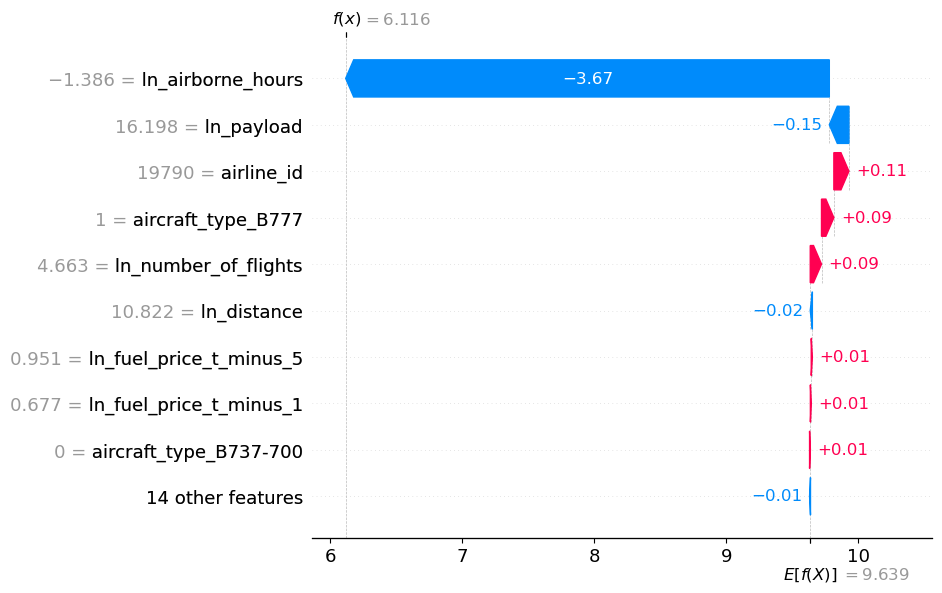

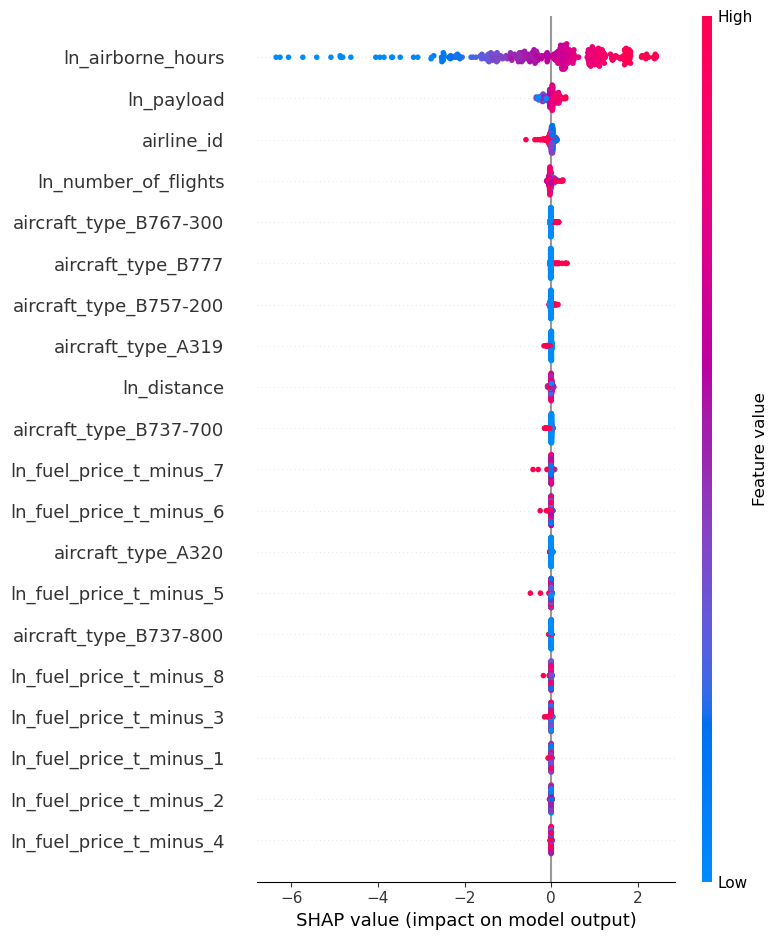

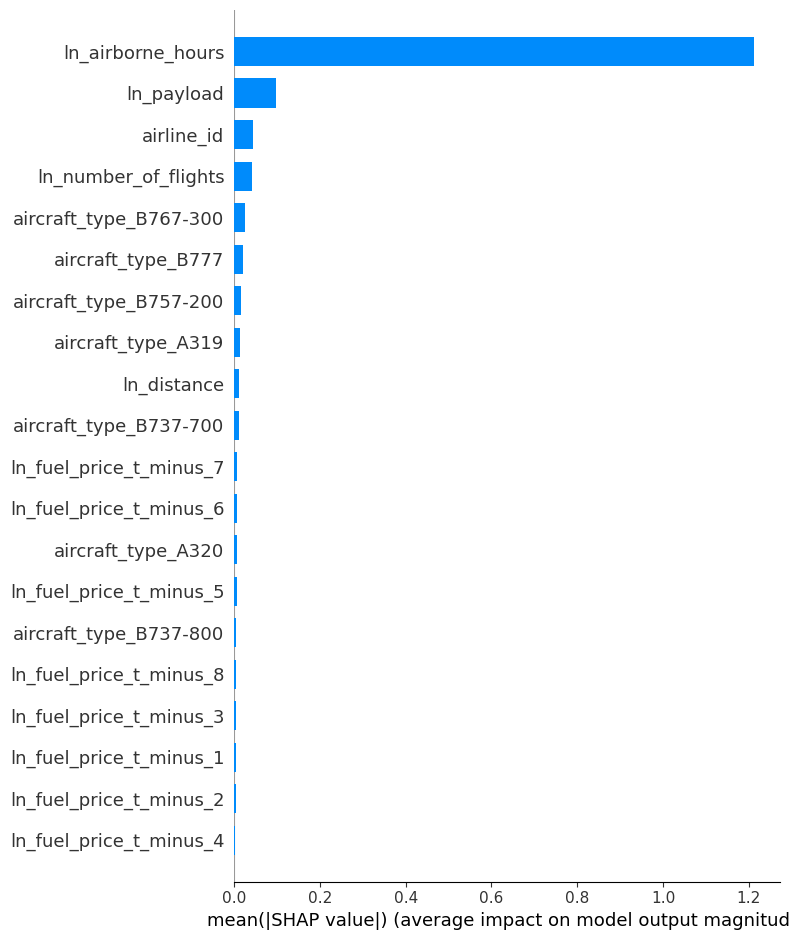

In [27]:
import shap
explainer = shap.Explainer(rf_model, X_train)
shap_values = explainer(X_test)

shap.plots.waterfall(shap_values[0])

shap.summary_plot(shap_values, X_test)

shap.summary_plot(shap_values, X_test, plot_type="bar")

/var/folders/6l/xz1x7fyj3m7bjp8ctvtbmy3r0000gn/T/ipykernel_58299/2094899742.py:40: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  axes[row_index, col_index].plot(lowess_x, lowess_y, 'r-', linewidth=3, color='#e76000')
/var/folders/6l/xz1x7fyj3m7bjp8ctvtbmy3r0000gn/T/ipykernel_58299/2094899742.py:40: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  axes[row_index, col_index].plot(lowess_x, lowess_y, 'r-', linewidth=3, color='#e76000')
/var/folders/6l/xz1x7fyj3m7bjp8ctvtbmy3r0000gn/T/ipykernel_58299/2094899742.py:40: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  axes[row_index, col_index].plot(lowess_x, lowess_y, 'r-', linewidth=3, color='#e76000')
/var/folde

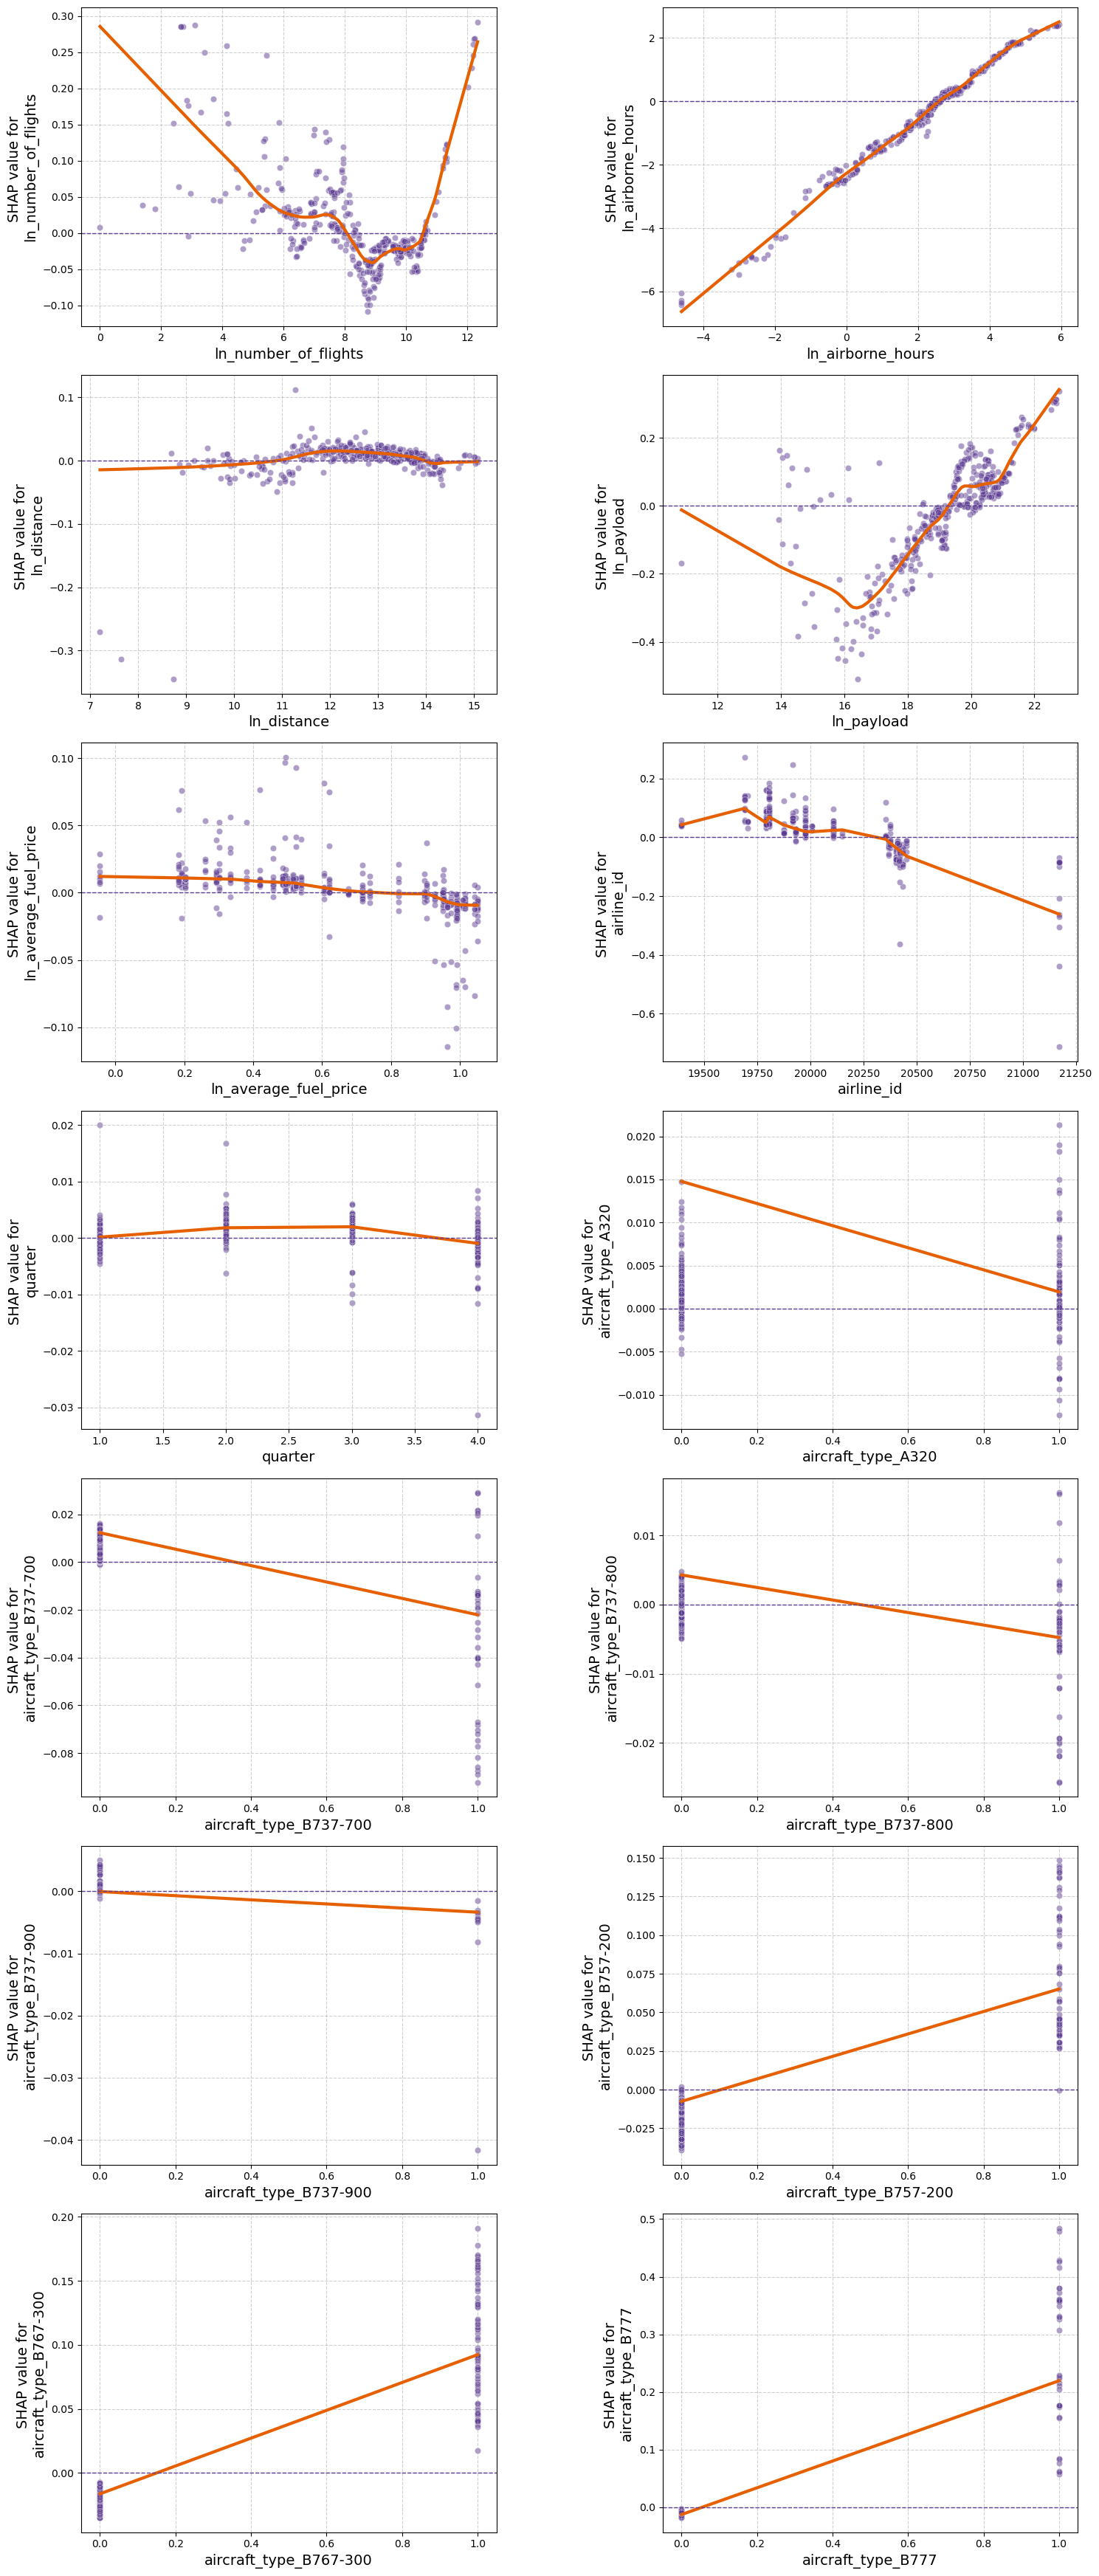

In [15]:
import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns

# 确定要绘制的所有特征
features_to_plot = X_test.columns.tolist()  # 获取所有特征

# 确保 shap_values 的形状与 X_test 匹配
assert shap_values.shape[1] == len(features_to_plot), "SHAP values and feature count do not match!"

# 计算需要的行数和列数
num_features = len(features_to_plot)
num_rows = (num_features + 1) // 2  # 向上取整
num_cols = 2

# 创建一个包含多个子图的图形
fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 5 * num_rows))

# 遍历特征并绘制图表
for i, feature_name in enumerate(features_to_plot):
    # 计算子图的行和列索引
    row_index = i // num_cols
    col_index = i % num_cols

    # 使用 Seaborn 绘制散点图
    sns.scatterplot(
        x=X_test[feature_name], 
        y=shap_values[:, i].values, 
        ax=axes[row_index, col_index], 
        color='#5d3c93', alpha=0.5
    )

    # 执行 LOWESS 平滑
    lowess = sm.nonparametric.lowess(shap_values[:, i].values, X_test[feature_name], frac=0.3)

    # 提取 LOWESS 结果
    lowess_x, lowess_y = lowess.T

    # 绘制 LOWESS 曲线
    axes[row_index, col_index].plot(lowess_x, lowess_y, 'r-', linewidth=3, color='#e76000')

    # 设置 x 和 y 轴标签
    axes[row_index, col_index].set_xlabel(feature_name, fontsize=14)
    axes[row_index, col_index].set_ylabel(f'SHAP value for \n{feature_name}', fontsize=14)

    # 添加网格背景
    axes[row_index, col_index].grid(True, linestyle='--', alpha=0.6)

    # 在每个子图上绘制 y=0 的虚线
    axes[row_index, col_index].axhline(y=0, color='#5d3c93', linestyle='--', linewidth=1)

# 去掉最后一行中的空白子图
if num_features < num_rows * num_cols:
    for i in range(num_features, num_rows * num_cols):
        fig.delaxes(axes.flatten()[i])

# 调整子图之间的间距
plt.tight_layout()
plt.subplots_adjust(wspace=0.4)  # 增加列之间的间距
plt.show()